In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# =================================================================
# 1. SETUP AND REPRODUCIBILITY
# =================================================================
SEED = 42
np.random.seed(SEED)

# =================================================================
# 2. GENERATING TRAINING DATA (Healthy Readings Only)
# =================================================================
n_train = 300

# Generating two normal operating modes (Light load vs Full load)
X_train, _ = make_blobs(
    n_samples=n_train,
    centers=[[65.0, 9.5], [72.0, 12.0]],
    cluster_std=1.5,
    random_state=SEED
)

print("--- TRAINING DATA SUMMARY (Healthy Motor) ---")
print("Total Training Samples:", X_train.shape[0])
print(f"Temperature Range: {X_train[:, 0].min():.1f}°C to {X_train[:, 0].max():.1f}°C")
print(f"Current Range: {X_train[:, 1].min():.1f}A to {X_train[:, 1].max():.1f}A")






--- TRAINING DATA SUMMARY (Healthy Motor) ---
Total Training Samples: 300
Temperature Range: 60.1°C to 76.6°C
Current Range: 6.5A to 15.4A


In [6]:
# =================================================================
# 3. GENERATE TEST DATA (Healthy + Injected Faults)
# =================================================================
n_test_normal = 100

# Normal test readings (same distribution, different seed)
X_test_normal, _ = make_blobs(
    n_samples=n_test_normal,
    centers=[[65.0, 9.5], [72.0, 12.0]],
    cluster_std=1.5,
    random_state=SEED + 1
)

# Fault 1: Overheating (High temp, normal current)
fault_overheat = np.column_stack([
    np.random.uniform(85, 100, 14),
    np.random.uniform(9, 13, 14)
])

# Fault 2: Overcurrent (Normal temp, high current)
fault_overcurrent = np.column_stack([
    np.random.uniform(64, 74, 13),
    np.random.uniform(18, 25, 13)
])

# Fault 3: Total Breakdown (High temp, high current)
fault_breakdown = np.column_stack([
    np.random.uniform(90, 105, 13),
    np.random.uniform(20, 28, 13)
])

# Combine all anomalies together
X_test_outlier = np.vstack([fault_overheat, fault_overcurrent, fault_breakdown])

# Combine normal and anomaly data for testing
X_test = np.vstack([X_test_normal, X_test_outlier])

# Create true labels: 1 for healthy, -1 for faults
y_test_true = np.concatenate([
    np.ones(n_test_normal),
    -np.ones(len(X_test_outlier))
])

print(f"\nTEST DATA: {n_test_normal} healthy + {len(X_test_outlier)} faults = {len(X_test)} total")



TEST DATA: 100 healthy + 40 faults = 140 total


In [7]:
# =================================================================
# 4. FEATURE SCALING
# =================================================================
# Scale data so Temperature and Current values contribute equally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =================================================================
# 5. TRAIN THE ONE-CLASS SVM
# =================================================================
# nu=0.05 means we expect at most 5% outliers in our training data
oc_svm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
oc_svm.fit(X_train_scaled)

print("\n--- MODEL TRAINING COMPLETE ---")
print("Support Vectors found:", oc_svm.support_vectors_.shape[0])



--- MODEL TRAINING COMPLETE ---
Support Vectors found: 23


In [8]:
# =================================================================
# 6. INFERENCE AND PREDICTIONS
# =================================================================
y_pred = oc_svm.predict(X_test_scaled)
scores = oc_svm.score_samples(X_test_scaled)

# =================================================================
# 7. EVALUATION METRICS
# =================================================================
# Calculate Confusion Matrix elements manually
TP = np.sum((y_pred == 1) & (y_test_true == 1))
TN = np.sum((y_pred == -1) & (y_test_true == -1))
FP = np.sum((y_pred == 1) & (y_test_true == -1))
FN = np.sum((y_pred == -1) & (y_test_true == 1))

# Calculate rates
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
accuracy = (TP + TN) / len(y_test_true)
fdr = TN / (TN + FP)  # Fault Detection Rate

print("\n" + "="*50)
print("             EVALUATION RESULTS")
print("="*50)
print(f"True Healthy predicted Healthy (TP): {TP}")
print(f"True Healthy predicted Fault   (FN): {FN} (False Alarms)")
print(f"True Fault predicted Healthy   (FP): {FP} (Dangerous!)")
print(f"True Fault predicted Fault     (TN): {TN} (Faults Caught)")
print("-" * 50)
print(f"Accuracy               : {accuracy:.4f}")
print(f"Precision (Healthy)    : {precision:.4f}")
print(f"Recall (Healthy)       : {recall:.4f}")
print(f"F1-Score               : {f1:.4f}")
print(f"Fault Detection Rate   : {fdr:.4f} ({TN}/{TN+FP} caught)")
print("="*50)



             EVALUATION RESULTS
True Healthy predicted Healthy (TP): 95
True Healthy predicted Fault   (FN): 5 (False Alarms)
True Fault predicted Healthy   (FP): 0 (Dangerous!)
True Fault predicted Fault     (TN): 40 (Faults Caught)
--------------------------------------------------
Accuracy               : 0.9643
Precision (Healthy)    : 1.0000
Recall (Healthy)       : 0.9500
F1-Score               : 0.9744
Fault Detection Rate   : 1.0000 (40/40 caught)


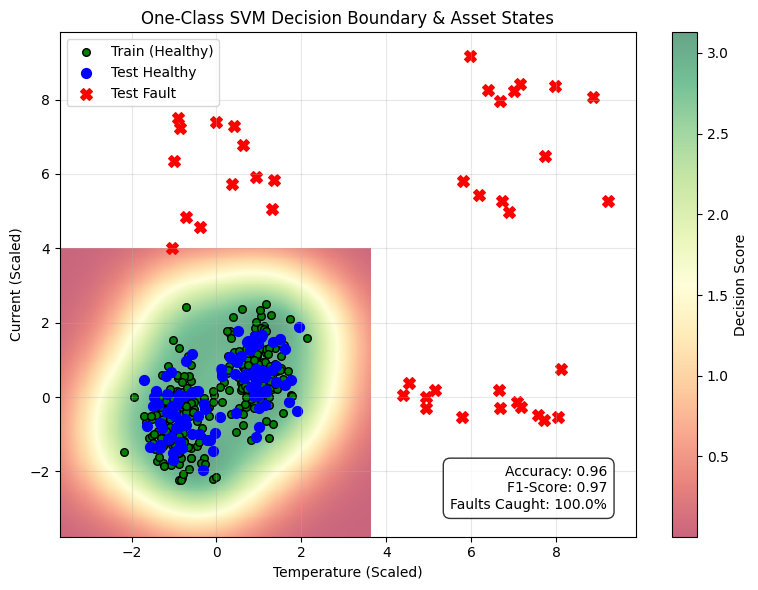

In [9]:
# =================================================================
# 8. VISUALISATION MESH
# =================================================================
# Create a grid of points to map out the decision boundary boundary
x_min, x_max = X_train_scaled[:, 0].min() - 1.5, X_train_scaled[:, 0].max() + 1.5
y_min, y_max = X_train_scaled[:, 1].min() - 1.5, X_train_scaled[:, 1].max() + 1.5

x_grid = np.linspace(x_min, x_max, 300)
y_grid = np.linspace(y_min, y_max, 300)
xx, yy = np.meshgrid(x_grid, y_grid)

# Flatten grid to predict and reshape back
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = oc_svm.score_samples(grid_points)
Z = Z.reshape(xx.shape)

# =================================================================
# 9. PLOT GRAPHICS
# =================================================================
plt.figure(figsize=(8, 6))

# Color the background regions based on decision scores
plt.pcolormesh(xx, yy, Z, cmap='RdYlGn', alpha=0.6, shading='auto')
plt.colorbar(label='Decision Score')

# Draw the exact threshold line (where score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='blue', linestyles='--')

# Plot dataset points
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c='green', edgecolors='k', s=30, label='Train (Healthy)')
plt.scatter(X_test_scaled[y_test_true == 1, 0], X_test_scaled[y_test_true == 1, 1], c='blue', marker='o', s=50, label='Test Healthy')
plt.scatter(X_test_scaled[y_test_true == -1, 0], X_test_scaled[y_test_true == -1, 1], c='red', marker='X', s=70, label='Test Fault')

# Text box for metrics inside the plot
metrics_box = f"Accuracy: {accuracy:.2f}\nF1-Score: {f1:.2f}\nFaults Caught: {fdr*100:.1f}%"
plt.text(0.95, 0.05, metrics_box, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.title('One-Class SVM Decision Boundary & Asset States')
plt.xlabel('Temperature (Scaled)')
plt.ylabel('Current (Scaled)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Save and show visual results
plt.tight_layout()
output_filename = 'one_class_svm_boundary.png'
plt.savefig(output_filename, dpi=100)
#print(f"\n[SUCCESS] Performance plot saved as: {output_filename}")
plt.show()